# CNN Image Classification Report (CIFAR-100)




## Introduction



##Key Words

   **Convolutional neural networks (CNN):**
   are neural network architectures that is inspired by the human visual system and designed to process images by capturing spatial relationships between pixels.

   **Convolutional layer:**
   is responsiple for extracting important features from the input data and it applies a set of learnable filters that slide over the image and compute the dot product between the filter weights and corresponding image patches, producing feature maps.

   **Dense layer:**
   performs high level reasoning using extracted features and produces the final classification.

   **Flatten layer:**
  converts the multi dimensional feature maps into a one dimensional vector after convolution and pooling then this vector is passed to the dense layer.

   **Max pooling:**
  selects the maximum value from each region of the feature map, capturing the most prominent features.

   **Activation Function:**
  introduces non linearity into the network allowing it to learn complex patterns beyond simple linear relationships.
  
  - ReLU: Outputs the input directly if positive and outputs zero otherwise. Is most widely used activation function because it is simple, fastto compute and avoids the vanishing gradient problem. Used as default in my convolutional and dense layers.

  - sigmoid: squashes output between the range 0 and 1.Now rarely used in hidden layers because it suffers from the gradient vanishing gradient problem

  - tanh: Similar to sigmoid but outputs values between -1 and 1 making it zero centered, which often makes learning faster than sigmoid because gradients are stronger. It also suffers from vanishing gradients in deep networks.

  - elu: is an advanced version of relu activation function that outputs small negative values for negative inputs instead of a zero. This prevents so called dead neurons problem where ReLU neurons get stuck at zero and stop learning.

  - selu: A scaled varsion of elu that automaticly normalises layer outputs toward a mean of zero and standard deviation of one during training. This makes training more stable witouth needing additional technigues like batch normalization.

  - softmax: Used exclusevily in the output layer in my model. It converts raw output scores into probabilities that sum to one across all classes.

   **Optimizer:**
   The optimizer is the algorithm that updates the models training based on calculated loss. It determines how large each update step is and which direction. Different optimizers use differents strategies for updating weights:

   - SGD:  simple gradient descent, it is slow butstable

   - Adam: adaptive learning rates per parameter, it is fast and realible

   - RMSprop: Adapts learning rate based on recent gradients

   - Adamax: Stable varient of adam for noisy gradients

   - Nadam: adam with nesterow momentum for faster convergence

   **Learning rate:**
 Is a key hyperparameter that controls how quickly a model learns by determining the step size during weight updates. Too high may overshoot minimum, too low may slow down learning.

   **Epoch**
   is one complete pass of the entire training dataset through the model. During each epoch, every training sample is processed, the model calculates the prediction error using a loss fuction and updates its weights through backpropagation and optimization algorithm

   **Batch Size**
  hyperparameter that determines the number of training records used in one forward and backward pass of the neural network. in other words the batch size refers to the number of samples used in each of these smaller batches during training.

   **Early Stopping:**
  is a regularization strategy that monitors the model's performance on validation set during training. When the validation loss stops deceasing for specified number of epochs(patience) then training is paused.

   **Overfitting:**
  Overfitting hapens when the model learns too much from the training data, including noise and outlier. It performs very well on training data but poorly on test data. Overfitting happens often because model is too complex, too many features, very little data, no regularization, high variance.

   **Feature Mapping:**
  is a technigue to transform input data from a lower dimensional space to a higher dimensional space, where it can be more easily analyzed or classified.

   **Hyperparameter Tuning:**
  it is the process of selecting the optimal values for machine learning model's hyperparameters.

   **Vanishing Gradient Problem:**
  Vanishing gradients slow or stop learning in earlier layers. It occurs when gradients become extremely small during backpropagation, causing earlier layers to learn very slowly or stop learning completely.

   **CIFAR-100:**
  Is a dataset that is widely used in the field of computer vision. Developed by the Canadian Institute for Advanced Research (CIFAR), the CIFAR-100 dataset consists of 60,000 color images partitioned into 100 classes, with each class holding 600 images. The dataset is further divided into 50,000 training images and 10,000 testing images. Each image in the CIFAR-100 dataset is a 32x32 color image, which poses a substantial challenge due to its low resolution.




##Task 1

In [1]:
#importing all the neede libaries
import numpy as np
import tensorflow as tf
import keras
from keras import datasets, layers, models, callbacks
import matplotlib.pyplot as plt
import pandas as pd
from keras.src.metrics.accuracy_metrics import accuracy
from keras.src.metrics import metric

In [2]:
# Picking 10 classes (CIFAR-100 label ids, 0-99)
selected_classes = [0, 51, 52, 53, 54, 8, 13, 48, 58, 90]
N_classes = len(selected_classes)

#Limiting images per class to avoid memory issues
#CIFAR-100 has 500 train images per class_ I am using 400
#CIFAR-100 has 100 test images per class - I am using all 100
imag_per_class_train= 400
imag_per_class_test= 100

#Loading the full CIFAR-100 dataset, the dataset is already split into train and test by keras
#label_mode='fine' gives 100 specific classes.
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar100.load_data(label_mode='fine')

#function for subset filtering
#extracts balanced subset of images from the dataset, and returns filtered and normalised image array and remapped labels
def make_subset(x,y, classes, limit):
  #flatten labels
  y = y.flatten()
  #remapping original dataset labels to 0,1,2...
  class_map = {c: i for i, c in enumerate(classes)}
  #collect indices for each selected class up to the limit
  idxs = []
  for c in classes:
    c_idxs = np.where( y== c)[0][:limit]
    idxs.extend(c_idxs)
  idxs = np.array(idxs)
  #shuffle to mix classes
  np.random.shuffle(idxs)
  #normalizing pixel values from 0-225 to 0.0-1.0
  x_sub = x[idxs].astype("float32") / 255.0
  y_sub = np.array([class_map[y[i]] for i in idxs])
  return x_sub, y_sub
#
np.random.seed(42)
tf.random.set_seed(42)

#building subsets for testing and training
x_train, y_train = make_subset(x_train_full, y_train_full, selected_classes, imag_per_class_train)
x_test, y_test = make_subset(x_test_full, y_test_full, selected_classes, imag_per_class_test)

#verifying shapes
print("Train:" , x_train.shape, "Test:", x_test.shape)



169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2357s 14us/step
Train: (4000, 32, 32, 3) Test: (1000, 32, 32, 3)


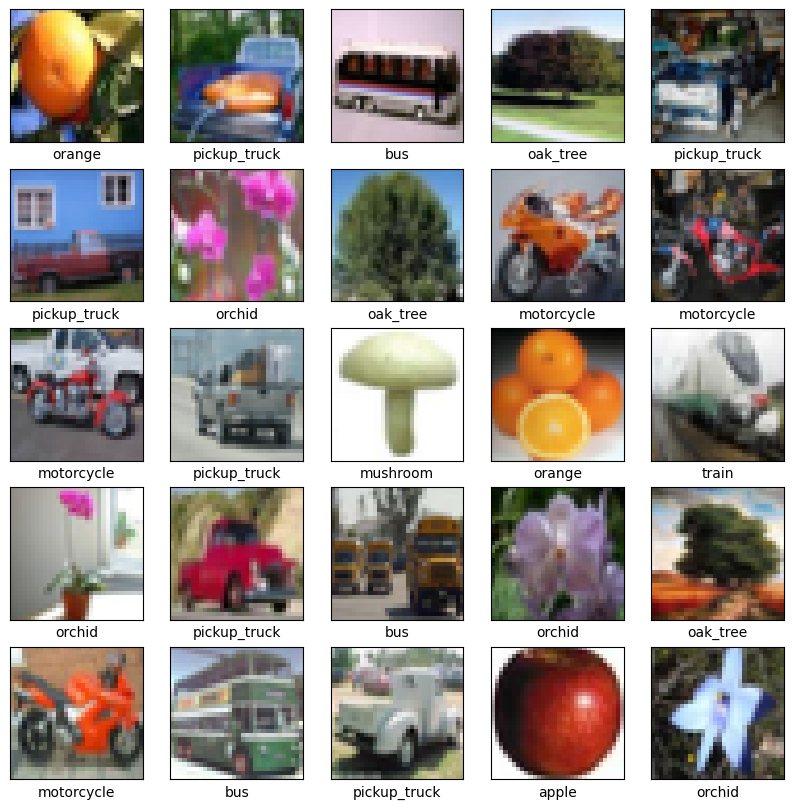

In [9]:
fine_labels = {0: 'apple', 51: 'mushroom', 52: 'oak_tree', 53: 'orange', 54: 'orchid', 8: 'bicycle', 13: 'bus', 48: 'motorcycle', 58: 'pickup_truck', 90: 'train'}

class_names = [fine_labels[c] for c in selected_classes]

plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(x_train[i])
  plt.xlabel(class_names[y_train[i]])
plt.show()

I chose subset one to contain visually different categories fruits/plants and vehicles because these are different enough that cnn should be able to differiantate them effectively.

two preprocessing steps were applied:
normalisation: pixels values were scaled from 0.225 to 0.0-1.0 by dividing by 225. Did this because neural networks train faster and more stabbly with small float inputs rather than large intergers

label remapping: original CIFAR-100 label IDs were remapped to sequential integers to match the 10 output neurons in the model. Without this the model would propably try to output values for neurons that don't exist.

I kept the images for their original 32x32 pixel size because that was what the tutorial did aswell.


##Task 2
building baseline cnn consisting of several convolutional and max pooling layers and several inner dense layers. using the tensorflow example as help

In [3]:
#baseline model as the example tensorflow shows

baseline_model = models.Sequential()

#convolutional base
#block one: learns low level features
baseline_model.add(layers.Input(shape=(32, 32, 3)))
baseline_model.add(layers.Conv2D(32, (3,3), activation='relu'))
baseline_model.add(layers.MaxPooling2D((2,2)))

#block two: learns mid level features
baseline_model.add(layers.Conv2D(64, (3,3), activation='relu'))
baseline_model.add(layers.MaxPooling2D((2,2)))

#extra conv layer at the end as was in the example
#learns higher level features
baseline_model.add(layers.Conv2D(64, (3,3), activation='relu'))

#dense head classification layes
baseline_model.add(layers.Flatten())
baseline_model.add(layers.Dense(64, activation='relu'))

#output softmax because it gives direct probability
baseline_model.add(layers.Dense(N_classes, activation='softmax'))

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

could have added drop out layers and batch normalization but didn't know if that was necesary or important for the exercise.

###baseline model architecture

Build the baseline model cnn to be similar to the TensorFlow CIFAR-10 tutorial, adapted for the exercise CIFAR-100 subset. The architecture consist three convolutional layers, one dense hidden layer, and a softmax output layer. I wasn't sure if the model should have more dense layers acording to the exercise task 1.

- optimizer: Adam learning rate 0.001

- loss. sparse categorical crossentropy

- batch size: 32

- epochs: 30



##Task 3 & 4
training and compailing the baseline model. and evualating the model performance on test set

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.3175 - loss: 1.8462 - val_accuracy: 0.4425 - val_loss: 1.4930
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5014 - loss: 1.3935 - val_accuracy: 0.5550 - val_loss: 1.2538
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5778 - loss: 1.1945 - val_accuracy: 0.5775 - val_loss: 1.1615
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6150 - loss: 1.0895 - val_accuracy: 0.6050 - val_loss: 1.0590
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.6533 - loss: 0.9747 - val_accuracy: 0.6650 - val_loss: 0.9199
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6850 - loss: 0.8788 - val_accuracy: 0.6450 - val_loss: 0.9916
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7125 - loss: 0.8023 - val_accuracy: 0.6575 - val_loss: 0.8824
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7375 - loss: 0.7388 - val_accu

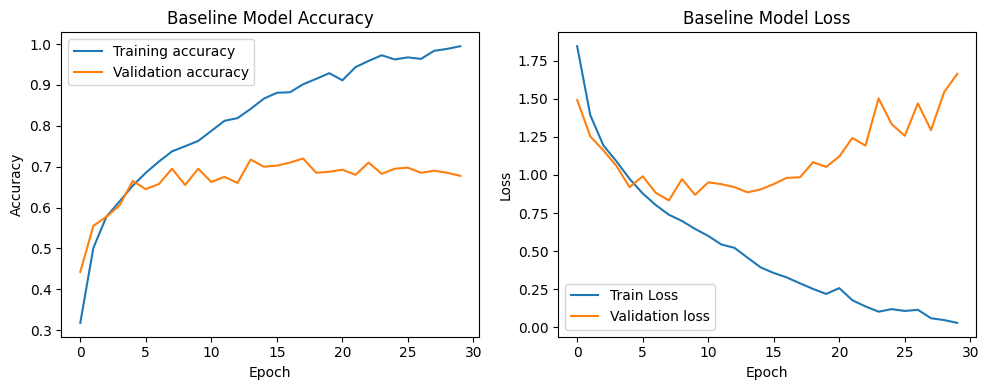

In [ ]:
#compiling and training baseline
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_base = baseline_model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

#evulating on test set
test_loss, test_acc = baseline_model.evaluate(x_test, y_test, verbose=2)
print(f"\nBaseline Test Accuracy: {test_acc:.3f}")
print(f"Baseline Test Loss: {test_loss:.3f}")

#plotting the training history
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(history_base.history['accuracy'], label='Training accuracy')
plt.plot(history_base.history['val_accuracy'], label= 'Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Baseline Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

###Results

The model achieved test accuracy of 73.4%  which is above the random change of 10% for a 10 class problem. This confirms that even a simple CNN can learn important features from 32x32 images.

The model shows clear signs of overfitting. Training accuracy increased from 31.7% at epoch 1 to 99.5% at epoch 30, while the validation accuracy remained much lower and fluctuated around approximately 67-72% during later epochs. This creates a gap between training and validation accuracy which indicates that the model was becoming specialised to the training data.
The highest validation accuracy 72.0% of was reached at epoch 18.

The training loss also decreased consistently from 1.846 at epoch 1 to 0.028 at epoch 30, which shows that the model became confident on in its predictions on the trainig data. In contrast, the validation loss increased from 1.493 at epoch 1  to 1.664 at epoch 30.at epoch 30 the difference between training and validation loss was approximately 1.636, which confirms that the model memorised the training data rather than learning general features.

the model is overfitting probably because the model has no reguralization and too many epochs. The baseline model I didn't add dropout layers or batch normalization. These regularization methods prevents the models from fitting noise in the training data. A dropout layer after each conv block would have randomly disapled neurons during training, forcing the model to learn more robust features. from the results we see that the optimal stopping point was epoch 18 where val_acc= 72.0%. Running more epochs after this point only made the model worse on unseen data. Maybe early stopping with smaller patience would have been better.

###test set evaluation
when tested on the seperate test set the baseline model achieved a test accuracy of 73.4% and a test loss of 1.456. The test accuracy is substanttially higher than the 10% random change accuracy for 10-class classification problem, demonstrating that the CNN has learned meaningfull features from the images and can correctly classify a big proportion of unseen samples.

The test accuracy of 73.4 also indicates that the model is able to generalise well enough. But the large gap between 99.5% training accuracy and 68-72% validation accuracy indicates overfitting. The test loss of 1.456, compared with the training loss of 0.028, also supports this. Therefore 73.4% will be used as the baseline for comparing the following experiments.

##Task 5
doing the experiments. I decided to do function that build the model for easier experimenting and a function that runs the experiments the training compiling and evulating of the models.

In [4]:
#making a function to build a model easier later if something needs to be modified

def build_model(
    n_classes = N_classes, #output neurons, one per class
    conv_blocks = 2,      #number of Conv2D + MaxPooling pairs
    base_filters = 32,    #filters in first conv; doubles each block
    kernel_size = (3,3),  #size of the convolutional filter window
    conv_act = 'relu',  #activation function for conv layer
    dense_units = 64, #neurons in each dense layer
    dense_act = 'relu', #activation function for dense layers
    dropout_rate= 0.25,
    n_dense = 1 , #how many dense layers before output
    extra_conv = True
    ):
  m = models.Sequential()
  #input layer
  m.add(layers.Input(shape=(32,32,3)))
#Convolutional blocks
#in each block Conv2D extracts features and MaxPooling reduces spatial size
  filters = base_filters
  for _ in range(conv_blocks):
    #adding conv layers and maxpooling layers
    m.add(layers.Conv2D(filters, kernel_size, activation=conv_act, padding='same'))
    m.add(layers.MaxPooling2D((2,2)))
    if dropout_rate > 0:
      m.add(layers.Dropout(dropout_rate)) #adding dropout layer to reduce overfitting
    filters *= 2

  #adding flatten
  m.add(layers.Flatten())
  #adding dense layers, the n_dense controls how many layers
  for _ in range(n_dense):
    m.add(layers.Dense(dense_units, activation=dense_act))
    if dropout_rate >0:
      m.add(layers.Dropout(0.5))
    #output layer one neuron per class
  m.add(layers.Dense(n_classes, activation='softmax'))
  return m

#checking the model
build_model().summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#making a function to handle all expirements
#storing results in list for comparison table

#collecting all expirement results in results list
results = []



def run_expirement(label, optimizer='adam', batch_size=32, epochs=30, **model_kwargs):
  #building fresh model for each expirement
  #**model_kwargs passes paraameters to build model
  model = build_model(**model_kwargs)
  #compiling with specified optimizer and standard classification loss
  model.compile(
      optimizer=optimizer,
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )
  #using early stop
  early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8, restore_best_weights=True
    )
  #training model
  h = model.fit(
      x_train, y_train,
      epochs=epochs,
      batch_size=batch_size,
      validation_split=0.1,
      callbacks=[early_stop],
      verbose=1
  )

  # evualating on test set:
  test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
  val_acc = max(h.history['val_accuracy'])
  train_acc = max(h.history['accuracy'])

  #saving the results to the list
  results.append({'label':      label,
        'val_acc':    val_acc,
        'train_acc': train_acc,
        **model_kwargs,             # saves all model parameters used
        'optimizer':  str(optimizer),
        'batch_size': batch_size
                  })
  #printing the results
  print(f"[{label}]")
  print(f"  Test accuracy : {test_acc*100:.3f}%")
  print(f"  Best val acc  : {val_acc*100:.3f}%")
  print(f"  Epochs run    : {len(h.history['loss'])}")
  print()

  return model, h, test_acc

test to see the effect on the model accuracy by increasing the size and depth of the inner layers

In [ ]:
#expirementing different layer dephts and sizes
#testing how more conv blocks and larger dense layers affect accuracy
h= run_expirement("2_shallow_conv", conv_blocks= 1)
h= run_expirement("3_deeper_conv", conv_blocks= 3)
h= run_expirement("4_even_deeper-conv", conv_blocks= 4)
h= run_expirement("5_small_dense", dense_units= 32)
h= run_expirement("6_big_dense", dense_units= 256)
h= run_expirement("7_large_dense", dense_units= 512)
h= run_expirement("8_two_dense", n_dense= 2, dense_units= 128)
h= run_expirement("9_three_dense", n_dense= 3, dense_units= 128)



Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.2514 - loss: 2.0617 - val_accuracy: 0.4525 - val_loss: 1.7265
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3689 - loss: 1.7424 - val_accuracy: 0.5400 - val_loss: 1.4738
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4144 - loss: 1.5875 - val_accuracy: 0.5900 - val_loss: 1.3602
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4658 - loss: 1.4717 - val_accuracy: 0.5750 - val_loss: 1.2603
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4839 - loss: 1.4069 - val_accuracy: 0.6125 - val_loss: 1.1857
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5075 - loss: 1.3465 - val_accuracy: 0.6500 - val_loss: 1.1194
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5192 - loss: 1.2895 - val_accuracy: 0.6475 - val_loss: 1.0981
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5506 - loss: 1.2370 - val_accu


 Layer size & depht results
             label  val_acc
    2_shallow_conv   0.6850
     3_deeper_conv   0.7600
4_even_deeper-conv   0.7825
     5_small_dense   0.7000
       6_big_dense   0.7575
     7_large_dense   0.7650
       8_two_dense   0.7625
     9_three_dense   0.7375


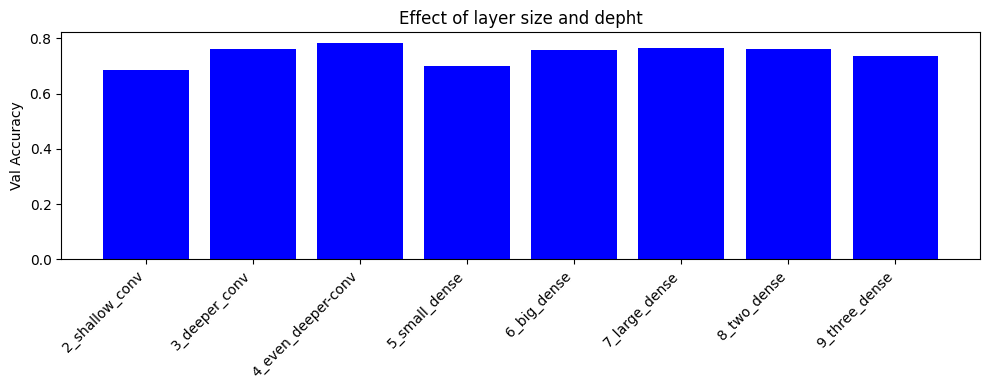

In [ ]:
#plotting results
layer_expirements= [r for r in results if r['label'].startswith(('1_','2_','3_','4_','5_','6_','7_','8_','9_'))]
df_layers = pd.DataFrame(layer_expirements)

print("\n Layer size & depht results")
print(df_layers[['label', 'val_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_layers['label'],df_layers['val_acc'], color= 'blue')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect of layer size and depht')
plt.tight_layout()
plt.show()


###Effects:

Changing the number of convolutional blocks had a clear effect on performance. Reducing the model to one convolutional block decreased the test accuracy to 69.5, compared with 73.4% for the baseline, which suggest that the shallower model didn't extract enough useful features. In contrast, increasing the depht to three convolutional blocks improved test accuracy to 79.8%, which is 6.4 pertancentage units improvement to the baseline. Increasing the depht even further to four conv blocks gave 79.2% result, slightly lower than the three block model. The three convolutional block architecture performed best, which shows that increasing convolutional depth can improve feature extraction but adding even more leaayers doesn't necessarily provide more benefits.

Increasing the size and number of dense layers generally improved performance compared with baseline, but adding more layers did not always produse more benefits. The small 32 unit dense layer achieved 73.4% the same as the baseline, while increasing the dense layer to 256 units improved accuracy to 77.9%. And when incresing the dance layer to 512 the accary decreased to 77.6% Using two dense layers achieved  77.3%, while three dense layers achieved 76.9%. These results show that increasing the capacity of dense layers can improve classification performance, but excessive dense layer depht doesn't necessarily improve generalisation.


In [ ]:
#testing also with different dropout layers or none of them to see their effect
h = run_expirement("dropout_025", dropout_rate=0.25)
h = run_expirement("dropout_050", dropout_rate=0.50)
h = run_expirement("no_dropout",  dropout_rate=0.0)

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.2072 - loss: 2.0954 - val_accuracy: 0.3950 - val_loss: 1.8154
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.3122 - loss: 1.8527 - val_accuracy: 0.5175 - val_loss: 1.5566
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.3911 - loss: 1.6969 - val_accuracy: 0.5375 - val_loss: 1.3980
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.4483 - loss: 1.5332 - val_accuracy: 0.5475 - val_loss: 1.3510
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.4747 - loss: 1.4360 - val_accuracy: 0.5875 - val_loss: 1.2390
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.4917 - loss: 1.3794 - val_accuracy: 0.6125 - val_loss: 1.1664
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.5158 - loss: 1.3178 - val_accuracy: 0.6550 - val_loss: 1.0621
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5383 - loss: 1.2621 - val_accu

###Effects:

I tested also adding dropout layers if that would help for overfitting in training.

Dropout was tested at rates of 0.25 and 0.50, along with a model without dropout. The results show that the dropout rate had an effect on  generalisation. The model with 0.25 dropout achieved 72.6% test accuracy, which was slightly below the baseline accuracy of 73.4%. Although its best validation accuracy reached 74.0%, this improvement didn't translate into better test performance.

The 0.50 dropout model performed best, achieving 76.1% test accuracy, which is higher than baseline. This suggests that stronger dropout provided more effective regularisation and helped reduce overfitting. In comparison the model without dropout achieved 72.7% test accuracy and showed increasing training accuracy while validation performance stopped improving, which indicates continued overfitting.




In [6]:
#expiementing different conv shappes kernel sizes
#test how the size of convolutional filter window affects accuracy
h= run_expirement("10_kernel1x1", kernel_size=(1,1))
h= run_expirement("11_kernel5x5", kernel_size=(5,5))
h= run_expirement("12_kernel7x7", kernel_size=(7,7))

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.1886 - loss: 2.1434 - val_accuracy: 0.2550 - val_loss: 2.0137
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.3044 - loss: 1.9160 - val_accuracy: 0.4250 - val_loss: 1.8227
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3472 - loss: 1.7798 - val_accuracy: 0.4600 - val_loss: 1.7026
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.3808 - loss: 1.6843 - val_accuracy: 0.4650 - val_loss: 1.6464
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4175 - loss: 1.5973 - val_accuracy: 0.4925 - val_loss: 1.5675
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4283 - loss: 1.5626 - val_accuracy: 0.5500 - val_loss: 1.4813
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4581 - loss: 1.4873 - val_accuracy: 0.5325 - val_loss: 1.4870
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.4675 - loss: 1.4480 - val_accu


 conv size and kernel size and shape results
       label  val_acc  train_acc
10_kernel1x1    0.620   0.577778
11_kernel5x5    0.715   0.708333
12_kernel7x7    0.725   0.819444


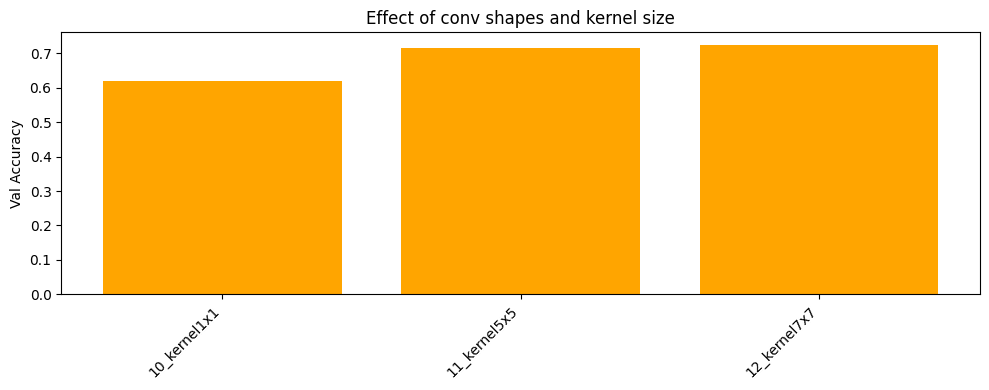

In [7]:
#plotting results
conv_kernel_expirements= [r for r in results if r['label'].startswith(('10_','11_','12_'))]
df_conv_kernel = pd.DataFrame(conv_kernel_expirements)

print("\n conv size and kernel size and shape results")
print(df_conv_kernel[['label', 'val_acc','train_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_conv_kernel['label'],df_conv_kernel['val_acc'], color= 'orange')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect of conv shapes and kernel size')
plt.tight_layout()
plt.show()


###Effects:

The 1x1 kernel achieved a test accuracy of 65.6% and increasing the kernel size to 5x5 improved the accuracy to 69.7%. the 7x7 kernel achieved the highest accuracy among the tested kernelsizes at 71.9% with best validation accuracy of 72.5%.

These results suggest that karger kernels were more effective than the 1x1 kernel because those can capture spatial information from a larger neighbourhood of bixels. However none of the larger kernel sizes were better than the original 3x3 baseline, which achieved 73.4% test accuracy. So the 3x3 kernel appears to provide the best balance for this model.


test that where we can see what is the effect of using different activation functions? how about combining the activation function choice with different network size and depth?

In [8]:
#experimenting different activation functions
#test different non linear activation functions in conv and dense layers
h = run_expirement("13_sigmoid_dense", conv_act='sigmoid')
h = run_expirement("14_tanh_dense", conv_act='tanh')
h = run_expirement("15_elu_conv", conv_act='elu')
h = run_expirement("16_selu_conv", conv_act='selu')
h = run_expirement("17_dense+sigmoid", dense_act='sigmoid')
h= run_expirement("18_dense_tanh", dense_act='tanh')


Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.0914 - loss: 2.3478 - val_accuracy: 0.1075 - val_loss: 2.3030
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.0975 - loss: 2.3028 - val_accuracy: 0.0725 - val_loss: 2.3036
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.0981 - loss: 2.3027 - val_accuracy: 0.0725 - val_loss: 2.3041
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.1031 - loss: 2.3027 - val_accuracy: 0.0725 - val_loss: 2.3043
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.1000 - loss: 2.3026 - val_accuracy: 0.0725 - val_loss: 2.3045
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.1039 - loss: 2.3029 - val_accuracy: 0.0725 - val_loss: 2.3049
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.1031 - loss: 2.3026 - val_accuracy: 0.0725 - val_loss: 2.3051
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.1031 - loss: 2.3026 - val_ac

In [ ]:
#plotting results
act_expirements= [r for r in results if r['label'].startswith(('13_','14_','15_','16_','17_','18_'))]
df_act = pd.DataFrame(act_expirements)

print("\n activation results")
print(df_act[['label', 'val_acc','train_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_act['label'],df_act['val_acc'], color= 'green')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect of different activation functions')
plt.tight_layout()
plt.show()


Observation:

In [ ]:
#testing combining activation + size
h= run_expirement("19_act_combo1", conv_act='elu', dense_act='tanh', conv_blocks= 3, dense_units= 256)
h= run_expirement("20_act_combo2", conv_act='selu', dense_act='sigmoid', conv_blocks= 2, dense_units= 128)


In [ ]:
#plotting results
act_size_expirements= [r for r in results if r['label'].startswith(('19_','20_'))]
df_act_size = pd.DataFrame(act_size_expirements)

print("\n activation and size combination results")
print(df_act_size[['label', 'val_acc','train_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_act_size['label'],df_act_size['val_acc'], color= 'pink')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect different activation and size combinations')
plt.tight_layout()
plt.show()


experimenting with various optimizers and learning rate. to see what is the effect on the resulting model accuracy

In [2]:
#expirementing different optimizers and learning rate
#tests different optimization algorithms and learning rate vlues
h = run_expirement("21_sgd", optimizer=tf.keras.optimizers.SGD(0.01))
h= run_expirement("22_sgd_momentum", optimizer=tf.keras.optimizers.SGD(0.01, momentum=0.09))
h= run_expirement("23_rmsprop", optimizer='rmsprop')
h= run_expirement("24_adamax", optimizer=tf.keras.optimizers.Adamax(0.001))
h= run_expirement("25_nadam", optimizer=tf.keras.optimizers.Nadam(0.001))
h= run_expirement("26_adam_lr_high", optimizer=tf.keras.optimizers.Adam(0.01))
h= run_expirement("27_adam_lr_mid", optimizer=tf.keras.optimizers.Adam(0.001))
h= run_expirement("28_adam_lr_low", optimizer=tf.keras.optimizers.Adam(0.0001))


NameError: name 'run_expirement' is not defined

In [ ]:
#plotting results
opt_expirements= [r for r in results if r['label'].startswith(('21_','22_','23_','24_','25_','26_','27_','28_'))]
df_opt = pd.DataFrame(opt_expirements)

print("\n optimazation results")
print(df_opt[['label', 'val_acc','train_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_opt['label'],df_opt['val_acc'], color= 'red')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect of different optimation functions')
plt.tight_layout()
plt.show()


experimenting with various batch sizes and epochs for training

In [ ]:
#expirementing with size and epochs
#Testing how batch size and number of training epochs affect
h= run_expirement("29_batch8", batch_size=8)
h= run_expirement("30_batch17", batch_size=17)
h= run_expirement("31_batch137", batch_size=137)
h= run_expirement("32:batch256", batch_size=256)
h= run_expirement("33_few_epochs", epochs=5)
h= run_expirement("34_many_epochs", epochs=40)
h= run_expirement("35_small_batch_longepoc", batch_size=17, epochs=40)
h= run_expirement("36_large_batch_shortepoc", batch_size=256, epochs=10)


Epoch 1/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.2342 - loss: 2.0829 - val_accuracy: 0.3975 - val_loss: 1.7552
Epoch 2/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3322 - loss: 1.8173 - val_accuracy: 0.4350 - val_loss: 1.4922
Epoch 3/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4125 - loss: 1.6098 - val_accuracy: 0.5750 - val_loss: 1.3641
Epoch 4/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4681 - loss: 1.4521 - val_accuracy: 0.5475 - val_loss: 1.2547
Epoch 5/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4958 - loss: 1.3912 - val_accuracy: 0.6175 - val_loss: 1.1059
Epoch 6/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5333 - loss: 1.2894 - val_accuracy: 0.6550 - val_loss: 1.0263
Epoch 7/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5519 - loss: 1.2166 - val_accuracy: 0.6250 - val_loss: 1.0141
Epoch 8/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5714 - loss: 1.1601 - val_accu


 size an epoch changes results
                   label  val_acc  train_acc
               29_batch8   0.7550   0.781111
              30_batch17   0.7500   0.779167
             31_batch137   0.7025   0.643611
           33_few_epochs   0.6500   0.533889
          34_many_epochs   0.7175   0.696944
 35_small_batch_longepoc   0.7600   0.840556
36_large_batch_shortepoc   0.5775   0.486667


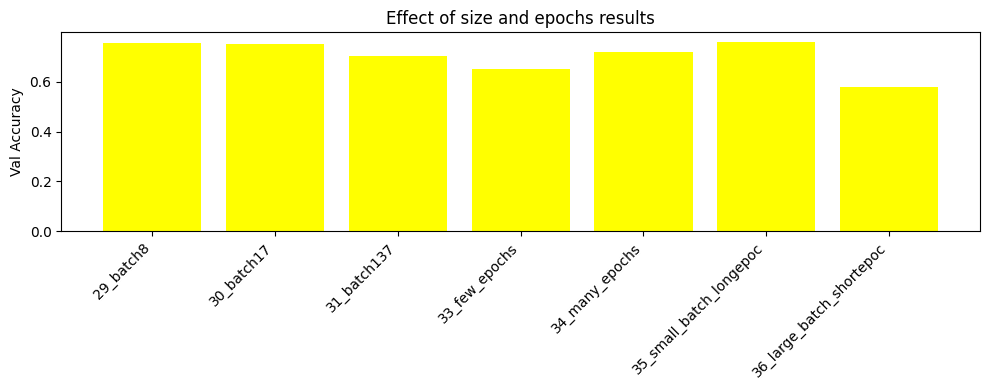

In [ ]:
#plotting results
size_epoch_expirements= [r for r in results if r['label'].startswith(('29_','30_','31_','32_','33_','34_','35_','36_'))]
df_size_epoch = pd.DataFrame(size_epoch_expirements)

print("\n size an epoch changes results")
print(df_size_epoch[['label', 'val_acc','train_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_size_epoch['label'],df_size_epoch['val_acc'], color= 'yellow')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect of size and epochs results')
plt.tight_layout()
plt.show()


In [ ]:
df_all_results= pd.DataFrame(results).sort_values('val_acc', ascending= False).reset_index(drop= True)

print("\n All Experiments ranked by Validation Accuracy")
print(df_all_results[['label', 'val_acc', 'train_acc', 'batch_size']].to_string(index= False))
print(f"\n Best: {df_all_results.iloc[0]['label']} val_acc={df_all_results.iloc[0]['val_acc']:.4f}")



 All Experiments ranked by Validation Accuracy
                   label  val_acc  train_acc  batch_size
      4_even_deeper-conv   0.7825   0.848333          32
           18_dense_tanh   0.7700   0.925000          32
           19_act_combo1   0.7650   0.946111          32
           7_large_dense   0.7650   0.966944          32
             15_elu_conv   0.7625   0.872778          32
             8_two_dense   0.7625   0.832222          32
 35_small_batch_longepoc   0.7600   0.840556          17
           3_deeper_conv   0.7600   0.804722          32
             6_big_dense   0.7575   0.923611          32
               29_batch8   0.7550   0.781111           8
              23_rmsprop   0.7525   0.851111          32
              30_batch17   0.7500   0.779167          17
        17_dense+sigmoid   0.7425   0.837222          32
              no_dropout   0.7425   0.994167          32
            11_kernel5x5   0.7400   0.782778          32
             dropout_025   0.7400   0.70


 ALL EXPERIMENTS RANKED BY VALIDATION ACCURACY
                   label  val_acc  batch_size
      4_even_deeper-conv   0.7825          32
           18_dense_tanh   0.7700          32
           19_act_combo1   0.7650          32
           7_large_dense   0.7650          32
             15_elu_conv   0.7625          32
             8_two_dense   0.7625          32
 35_small_batch_longepoc   0.7600          17
           3_deeper_conv   0.7600          32
             6_big_dense   0.7575          32
               29_batch8   0.7550           8
              23_rmsprop   0.7525          32
              30_batch17   0.7500          17
        17_dense+sigmoid   0.7425          32
              no_dropout   0.7425          32
            11_kernel5x5   0.7400          32
             dropout_025   0.7400          32
           9_three_dense   0.7375          32
            12_kernel7x7   0.7325          32
          27_adam_lr_mid   0.7300          32
           20_act_combo2   0.730

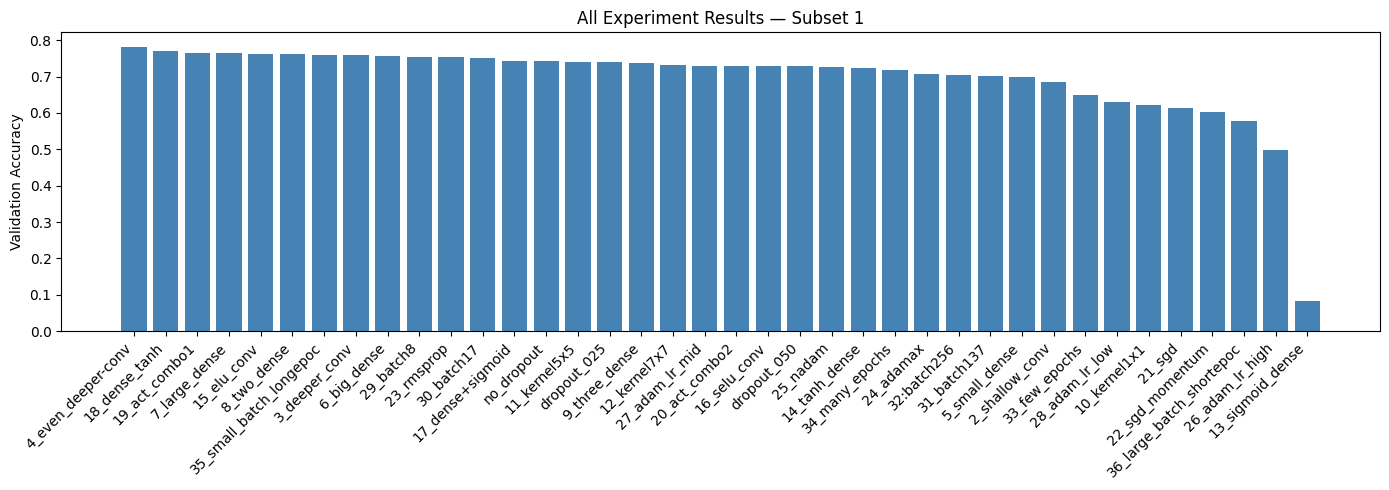

In [ ]:
# Convert results list to DataFrame and sort by best validation accuracy
df_all = pd.DataFrame(results).sort_values(
    'val_acc', ascending=False
).reset_index(drop=True)

print("\n ALL EXPERIMENTS RANKED BY VALIDATION ACCURACY")
print(df_all[['label','val_acc',
               'batch_size']].to_string(index=False))
print(f"\nBest config: {df_all.iloc[0]['label']}"
      f" — val_acc={df_all.iloc[0]['val_acc']:.4f}")

# Bar chart of all results for visual comparison in report
plt.figure(figsize=(14,5))
plt.bar(df_all['label'], df_all['val_acc'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Validation Accuracy')
plt.title('All Experiment Results — Subset 1')
plt.tight_layout()
plt.show()


##Task 6

Repeating the above experiment in (5) using another subset of the CIFAR-100

In [ ]:
# Picking 10 classes (CIFAR-100 label ids, 0-99)
selected_classes2 = [4, 30, 55, 72, 95, 19, 21, 43, 97, 3]
n_classes2 = len(selected_classes2)
images_per_class_tr= 400
images_per_class_ts= 100

target_size = (24, 24)

#building second subsset using the same make_subset function that was used before
x_train2, y_train2 = make_subset(x_train_full, y_train_full, selected_classes2, images_per_class_tr)
x_test2, y_test2 = make_subset(x_test_full, y_test_full, selected_classes2, images_per_class_ts)


print(f"subset 2 train: {x_train2.shape}")
print(f"subset 2 test: {x_test2.shape}")

subset 2 train: (4000, 32, 32, 3)
subset 2 test: (1000, 32, 32, 3)


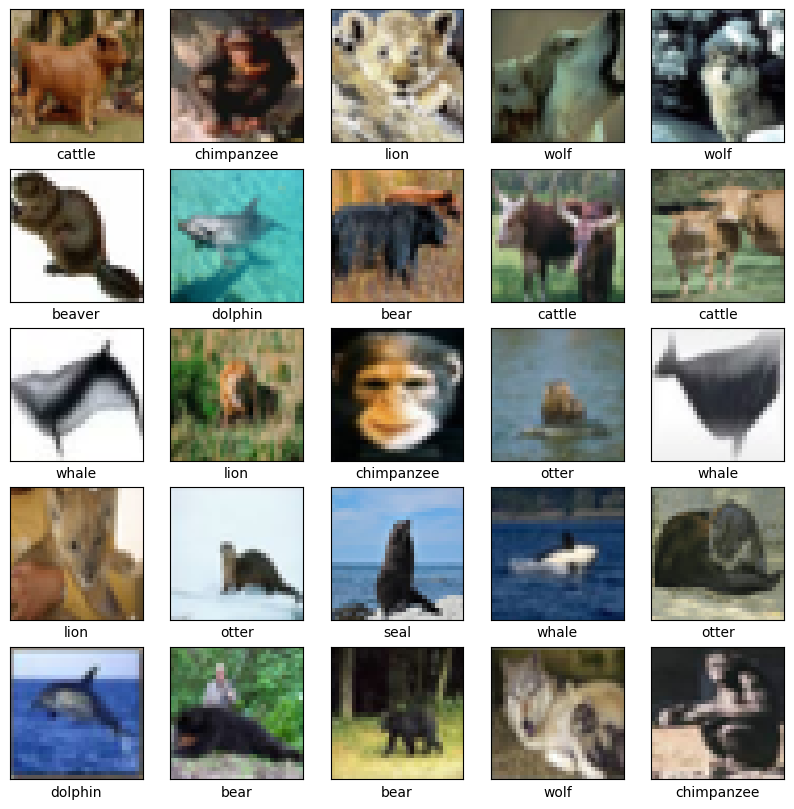

In [ ]:

fine_labels2 = {4: 'beaver', 30: 'dolphin', 55: 'otter', 72: 'seal', 95: 'whale', 19: 'cattle', 21: 'chimpanzee', 43: 'lion', 97: 'wolf', 3: 'bear'}
class_names2 = [fine_labels2[c] for c in selected_classes2]

plt.figure(figsize= (10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(x_train2[i])
  plt.xlabel(class_names2[y_train2[i]])
plt.show()


In [ ]:
#new list for subset 2
results2 = []

#doing the same function for expirements as before but for subset 2 tranin and testing
def run_expirement2(label, optimizer='adam', batch_size=32, epochs=30, **model_kwargs):
  model = build_model(**model_kwargs)
  model.compile(
      optimizer=optimizer,
      loss= 'sparse_categorical_crossentropy',
      metrics=['accuracy']
  )

  early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8, restore_best_weights=True
    )

  h= model.fit(
      x_train2, y_train2,
      epochs= epochs,
      batch_size= batch_size,
      validation_split=0.1,
      callbacks=[early_stop],
      verbose=1
  )

   # evualating on test set:
  test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
  val_acc = max(h.history['val_accuracy'])
  train_acc= max(h.history['accuracy'])
  #saving the results to the list
  results2.append({'label':      label,
        'val_acc':    val_acc,
        'train_acc': train_acc,
        **model_kwargs,             # saves all model parameters used
        'optimizer':  str(optimizer),
        'batch_size': batch_size
                  })
#printing the results
  print(f"[{label}]")
  print(f"  Test accuracy : {test_acc*100:.2f}%")
  print(f"  Best val acc  : {val_acc*100:.2f}%")
  print(f"  Epochs run    : {len(h.history['loss'])}")
  print()

  return model, h, test_acc


In [ ]:
#runing the same expirements as step 5
print("Subset 1 shape:", x_train.shape)   # e.g. (4000, 24, 24, 3)
print("Subset 2 shape:", x_train2.shape)

Subset 1 shape: (4000, 32, 32, 3)
Subset 2 shape: (4000, 32, 32, 3)


In [ ]:
#expirementing different layer dephts and sizes
#tests how adding more conv blocks and larger dense layers affect accuracy
h_base2 = run_expirement2("1_baseline")
h= run_expirement2("2_shallow_conv", conv_blocks= 1)
h= run_expirement2("3_deeper_conv", conv_blocks= 3)
h= run_expirement2("4_even_deeper-conv", conv_blocks= 4)
h= run_expirement2("5_small_dense", dense_units= 32)
h= run_expirement2("6_big_dense", dense_units= 256)
h= run_expirement2("7_large_dense", dense_units= 512)
h= run_expirement2("8_two_dense", n_dense= 2, dense_units= 128)
h= run_expirement2("9_three_dense", n_dense= 3, dense_units= 128)



Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.1889 - loss: 2.1288 - val_accuracy: 0.2700 - val_loss: 2.0280
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.2631 - loss: 1.9837 - val_accuracy: 0.3675 - val_loss: 1.8815
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.2850 - loss: 1.8940 - val_accuracy: 0.4000 - val_loss: 1.7662
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.3269 - loss: 1.8058 - val_accuracy: 0.3650 - val_loss: 1.7907
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.3667 - loss: 1.7370 - val_accuracy: 0.4125 - val_loss: 1.6264
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3686 - loss: 1.7169 - val_accuracy: 0.4325 - val_loss: 1.6533
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.3939 - loss: 1.6886 - val_accuracy: 0.4250 - val_loss: 1.5926
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3847 - loss: 1.6774 - val_accu


 Layer size & depht results
             label  val_acc  train_acc
        1_baseline   0.5300   0.518611
    2_shallow_conv   0.4800   0.491389
     3_deeper_conv   0.5400   0.480278
4_even_deeper-conv   0.5375   0.502500
     5_small_dense   0.4200   0.291111
       6_big_dense   0.5650   0.709722
     7_large_dense   0.5375   0.795000
       8_two_dense   0.5050   0.520000
     9_three_dense   0.4675   0.449722


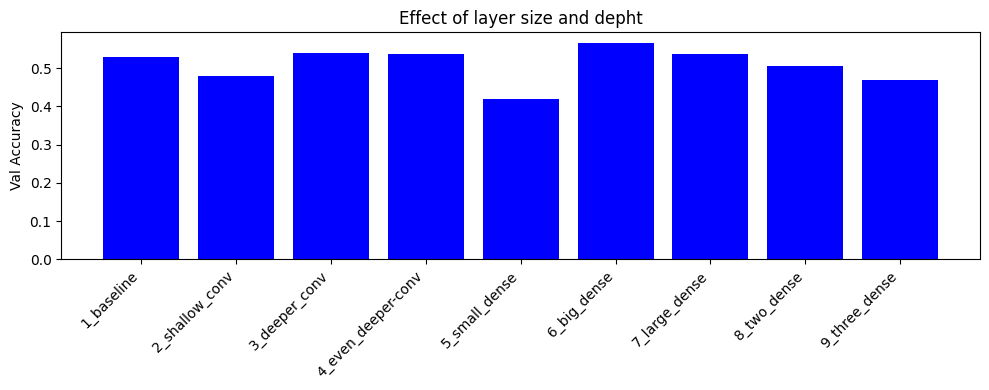

In [ ]:
#plotting results
layer_expirements2= [r for r in results2 if r['label'].startswith(('1_','2_','3_','4_','5_','6_','7_','8_','9_'))]
df_layers2 = pd.DataFrame(layer_expirements2)

print("\n Layer size & depht results")
print(df_layers2[['label', 'val_acc','train_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_layers2['label'],df_layers2['val_acc'], color= 'blue')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect of layer size and depht')
plt.tight_layout()
plt.show()


In [ ]:
#expiementing different conv shappes kernel sizes
#tests how the size of convolutional filter window affects accuracy
h= run_expirement2("10_kernel1x1", kernel_size=(1,1))
h= run_expirement2("11_kernel5x5", kernel_size=(5,5))
h= run_expirement2("12_kernel7x7", kernel_size=(7,7))

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1861 - loss: 2.1664 - val_accuracy: 0.2550 - val_loss: 2.0763
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2414 - loss: 2.0061 - val_accuracy: 0.3350 - val_loss: 1.9411
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.2678 - loss: 1.9277 - val_accuracy: 0.3400 - val_loss: 1.8824
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2933 - loss: 1.8827 - val_accuracy: 0.3850 - val_loss: 1.8212
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3147 - loss: 1.8462 - val_accuracy: 0.3775 - val_loss: 1.8196
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3203 - loss: 1.8145 - val_accuracy: 0.4175 - val_loss: 1.7634
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3267 - loss: 1.7996 - val_accuracy: 0.4275 - val_loss: 1.7381
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3300 - loss: 1.7941 - val_accu


 conv size and kernel size and shape results 2
       label  val_acc  train_acc
10_kernel1x1   0.4875   0.417222
11_kernel5x5   0.5250   0.520000
12_kernel7x7   0.5100   0.489444
10_kernel1x1   0.4525   0.390833
11_kernel5x5   0.5250   0.500833
12_kernel7x7   0.5000   0.516111


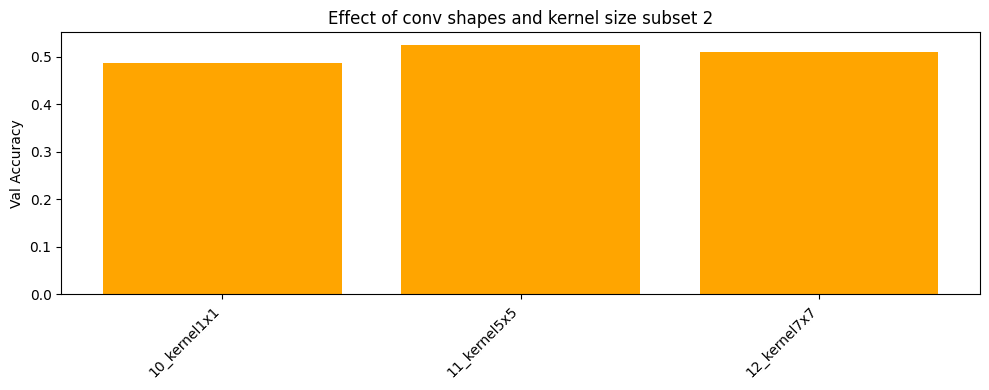

In [ ]:
#plotting results
conv_kernel_expirements2= [r for r in results2 if r['label'].startswith(('10_','11_','12_'))]
df_conv_kernel2 = pd.DataFrame(conv_kernel_expirements2)

print("\n conv size and kernel size and shape results 2")
print(df_conv_kernel2[['label', 'val_acc','train_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_conv_kernel2['label'],df_conv_kernel2['val_acc'], color= 'orange')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect of conv shapes and kernel size subset 2')
plt.tight_layout()
plt.show()


In [ ]:
#experimenting different activation functions
#test different non linear activation functions in conv and dense layers
h = run_expirement2("13_sigmoid_dense", conv_act='sigmoid')
h = run_expirement2("14_tanh_dense", conv_act='tanh')
h = run_expirement2("15_elu_conv", conv_act='elu')
h = run_expirement2("16_selu_conv", conv_act='selu')
h = run_expirement2("17_dense+sigmoid", dense_act='sigmoid')
h= run_expirement2("18_dense_tanh", dense_act='tanh')


Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.1786 - loss: 2.1860 - val_accuracy: 0.3625 - val_loss: 1.8799
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.2864 - loss: 1.9160 - val_accuracy: 0.3600 - val_loss: 1.7747
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.3269 - loss: 1.8303 - val_accuracy: 0.4200 - val_loss: 1.7000
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.3572 - loss: 1.7663 - val_accuracy: 0.4100 - val_loss: 1.6459
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3736 - loss: 1.7039 - val_accuracy: 0.4175 - val_loss: 1.6208
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3983 - loss: 1.6722 - val_accuracy: 0.4600 - val_loss: 1.5874
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.4183 - loss: 1.6044 - val_accuracy: 0.4400 - val_loss: 1.5527
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.4311 - loss: 1.5853 - val_accu

KeyboardInterrupt: 

In [ ]:
#plotting results
act_expirements2= [r for r in results2 if r['label'].startswith(('13_','14_','15_','16_','17_','18_'))]
df_act2 = pd.DataFrame(act_expirements2)

print("\n activation results")
print(df_act2[['label', 'val_acc','train_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_act2['label'],df_act2['val_acc'], color= 'green')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect of different activation functions')
plt.tight_layout()
plt.show()


In [ ]:
#combining activation + size
#tests combined activation
h= run_expirement2("19_act_combo1", conv_act='elu', dense_act='tanh', conv_blocks= 3, dense_units= 256)
h= run_expirement2("20_act_combo2", conv_act='selu', dense_act='sigmoid', conv_blocks= 2, dense_units= 128)


In [ ]:
#plotting results
act_size_expirements2= [r for r in results2 if r['label'].startswith(('19_','20_'))]
df_act_size2 = pd.DataFrame(act_size_expirements2)

print("\n activation and size combination results 2")
print(df_act_size2[['label', 'val_acc','train_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_act_size2['label'],df_act_size2['val_acc'], color= 'pink')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect different activation and size combinations subset 2')
plt.tight_layout()
plt.show()


In [ ]:
#expirementing different optimizers and learning rate
#tests different optimization algorithms and learning rate vlues
h = run_expirement2("21_sgd", optimizer=tf.keras.optimizers.SGD(0.01))
h= run_expirement2("22_sgd_momentum", optimizer=tf.keras.optimizers.SGD(0.01, momentum=0.09))
h= run_expirement2("23_rmsprop", optimizer='rmsprop')
h= run_expirement2("24_adamax", optimizer=tf.keras.optimizers.Adamax(0.001))
h= run_expirement2("25_nadam", optimizer=tf.keras.optimizers.Nadam(0.001))
h= run_expirement2("26_adam_lr_high", optimizer=tf.keras.optimizers.Adam(0.01))
h= run_expirement2("27_adam_lr_mid", optimizer=tf.keras.optimizers.Adam(0.001))
h= run_expirement2("28_adam_lr_low", optimizer=tf.keras.optimizers.Adam(0.0001))


In [ ]:
#plotting results
opt_expirements2= [r for r in results2 if r['label'].startswith(('21_','22_','23_','24_','25_','26_','27_','28_'))]
df_opt2 = pd.DataFrame(opt_expirements2)

print("\n optimazation results 2")
print(df_opt2[['label', 'val_acc','train_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_opt2['label'],df_opt2['val_acc'], color= 'red')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect of different optimation functions subset 2')
plt.tight_layout()
plt.show()


In [ ]:
#expirementing with size and epochs
#Tests how batch size and number of training epochs affect
h= run_expirement2("29_batch8", batch_size=8)
h= run_expirement2("30_batch17", batch_size=17)
h= run_expirement2("31_batch137", batch_size=137)
h= run_expirement2("32:batch256", batch_size=256)
h= run_expirement2("33_few_epochs", epochs=5)
h= run_expirement2("34_many_epochs", epochs=40)
h= run_expirement2("35_small_batch_longepoc", batch_size=17, epochs=40)
h= run_expirement2("36_large_batch_shortepoc", batch_size=256, epochs=10)


In [ ]:
#plotting results
size_epoch_expirements2= [r for r in results2 if r['label'].startswith(('29_','30_','31_','32_','33_','34_','35_','36_'))]
df_size_epoch2 = pd.DataFrame(size_epoch_expirements2)

print("\n size an epoch changes results 2")
print(df_size_epoch2[['label', 'val_acc','train_acc']].to_string(index=False))

plt.figure(figsize=(10,4))
plt.bar(df_size_epoch2['label'],df_size_epoch2['val_acc'], color= 'yellow')
plt.xticks(rotation= 45, ha='right')
plt.ylabel('Val Accuracy')
plt.title('Effect of conv shapes and kernel size subset 2')
plt.tight_layout()
plt.show()


In [ ]:
df1 = pd.DataFrame(results).sort_values('label').reset_index(drop=True)
df2 = pd.DataFrame(results2).sort_values('label').reset_index(drop=True)

#comparison
df_compare = pd.DataFrame({
    'expirement': df1['label'],
    'subset_val': df1['val_acc'].round(4),
    'subset2_val': df2['val_acc'].round(4),
    'difference': (df2['val_acc'] - df1['val_acc']).round(4)
})

print("\nSubset 1 vs Subset 2")
print(df_compare.to_string(index=False))

#plotting¨
x = range(len(df_compare))
width= 0.35
plt.figure(figsize=(14,5))
plt.bar([i - width/2 for i in x], df_compare['subset_val'], width,
        label='Subset 1 (fruits/vehicles)', color='blue')
plt.bar([i + width/2 for i in x], df_compare['subset2_val'], width,
        label='Subset 2 (animals)',         color='orange')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Validation Accuracy')
plt.title('Subset 1 vs Subset 2')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(f"Number of results in results2: {len(results2)}")
print(f"Number of results in results:  {len(results)}")
df2_check = pd.DataFrame(results2)
print(df2_check[['label', 'val_acc']])